# LCU 和 Block-Encoding
----

## LCU 数学原理

### 1. 为什么需要 LCU？
因为量子计算机天然擅长实现 unitary 操作, 但很多真正的操作并不是 unitary 的, 它们不能直接作为普通的量子门使用. 因此, 需要一种方法来将这些操作转换为 unitary 操作. 

LCU 的核心思想是: 若我们可以将 A 写为若干 unitary 的线性组合
$$
A=\sum_{j=0}^{L-1}\alpha_j U_j,\quad U_j^\dagger U_j=I
$$
则可以通过增加 ancilla, 把这个 nonunitary A 嵌入一个更大的 unitary 中.

### 2. 数值实验
本节统一选择
$$
A=0.9I+0.6X=0.9\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}+0.6\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}=\begin{bmatrix}
0.9 & 0.6 \\
0.6 & 0.9
\end{bmatrix}
$$
其本征值为 1.5 和0.3. 且 A 不是 unitary 的.

定义 LCU 的系数为 $\alpha_0=0.9, \alpha_1=0.6$, 则归一化系数为
$$
\alpha = \alpha_0+\alpha_1 = 1.5
$$
LCU 实际上嵌入 quantum circuit 的不是 A, 而是 $A/\alpha$. 所以
$$
\frac{A}{1.5}=\begin{bmatrix}
0.6 & 0.4\\
0.4 & 0.6
\end{bmatrix}
$$
此矩阵的本征值为 1 和0.2. 于是有
$$
\left\|\frac{A}{\alpha}\right\|\leq 1
$$

### 3. LCU 步骤
#### LCU 第一步: $PREPARE$.
定义一个 ancilla state:
$$
\ket{G}=\sum_j\sqrt{\frac{\alpha_j}{\alpha}}\ket{j}
$$
本例只有两个 unitary, 因此只需要 1 个 ancilla qubit.具体为
$$
\ket{G}=\sqrt{\frac{0.9}{1.5}}\ket{0}+\sqrt{\frac{0.6}{1.5}}\ket{1}=\sqrt{0.6}\ket{0}+\sqrt{0.4}\ket{1}
$$
定义 PREPARE 算子:
$$
O_{perp}\ket{0}=\ket{G}
$$
我们可以选择
$$
O_{perp}=\begin{bmatrix}
\sqrt{0.6} & -\sqrt{0.4} \\
\sqrt{0.4} & \sqrt{0.6}
\end{bmatrix}
$$

#### LCU 第二步: $SELECT$.
现在构造
$$
O_{sel}=\sum_j\ket{j}\bra{j}\otimes U_j
$$
结合本例, 有
$$
O_{sel}=\ket{0}\bra{0}\otimes I+\ket{1}\bra{1}\otimes X
$$
即
$$
O_{sel}\ket{j}\ket{G}=\ket{j}U_j\ket{G}
$$

#### LCU 第三步: $PREPARE^\dagger$
完整的 LCU unitary 为:
$$
W=(O_{perp}\otimes I)O_{sel}(O_{perp}^\dagger\otimes I)
$$
于是
$$
PREPARE \to SELECT \to PREPARE^\dagger
$$

### 4. 为什么其产生 $A/\alpha$.
计算
$$
(\bra{0}\otimes I)W(\ket{0} \otimes I)
$$
因为
$$
O_{perp}\ket{0}=\sum_j\sqrt{\frac{\alpha_j}{\alpha}}\ket{j}
$$
最终得到
$$
(\bra{0}\otimes I)W(\ket{0} \otimes I)=\sum_j\frac{\alpha_j}{\alpha}U_j=\frac{A}{\alpha}
$$
其实这就是下一节 Block Encoding 的定义.

In [1]:
# 手写实现 LCU
import numpy as np

I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)

alpha_0 = 0.9
alpha_1 = 0.6
alpha = alpha_0 + alpha_1

A = alpha_0 * I + alpha_1 * X

print("A =\n", A)
print("alpha =", alpha)
print("A / alpha =\n", A / alpha)


A =
 [[0.9+0.j 0.6+0.j]
 [0.6+0.j 0.9+0.j]]
alpha = 1.5
A / alpha =
 [[0.6+0.j 0.4+0.j]
 [0.4+0.j 0.6+0.j]]


In [2]:
# PREPARE 算子
p_0 = alpha_0 / alpha
p_1 = alpha_1 / alpha

PREPARE = np.array(
    [[np.sqrt(p_0), -np.sqrt(p_1)], [np.sqrt(p_1), np.sqrt(p_0)]], dtype=complex
)

# SELECT 算子
zero_block = np.zeros((2, 2), dtype=complex)

SELECT = np.block([[I, zero_block], [zero_block, X]])

print("PREPARE 算子：")
print(PREPARE)
print("SELECT 算子：")
print(SELECT)

PREPARE 算子：
[[ 0.77459667+0.j -0.63245553+0.j]
 [ 0.63245553+0.j  0.77459667+0.j]]
SELECT 算子：
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]


In [3]:
# 构建完整的 LCU
PREPARE_full = np.kron(PREPARE, I)
W_lcu = PREPARE_full.conj().T @ SELECT @ PREPARE_full

# 检查是否为 unitary
lcu_unitaty_error = np.linalg.norm(W_lcu.conj().T @ W_lcu - np.eye(4))
print("LCU unitarity error:", lcu_unitaty_error)

LCU unitarity error: 4.455241576525171e-16


In [4]:
# 检查左上角的 block
manual_lcu_block = W_lcu[0:2, 0:2]

print("左上角的 block:\n", manual_lcu_block)
print("A / alpha:\n", A / alpha)

# 检查误差
manual_lcu_block_error = np.linalg.norm(manual_lcu_block - A / alpha)
print("误差:\n", manual_lcu_block_error)

左上角的 block:
 [[0.6+0.j 0.4+0.j]
 [0.4+0.j 0.6+0.j]]
A / alpha:
 [[0.6+0.j 0.4+0.j]
 [0.4+0.j 0.6+0.j]]
误差:
 1.7554167342883506e-16


### 5. LCU 作用到状态上
选择 $\ket{\psi}=\ket{0}$, 则有
$$
\frac{A}{\alpha}\ket{0}=\begin{bmatrix}
0.6\\
0.4
\end{bmatrix}
$$
所以
$$
\frac{A}{\alpha}\ket{0}=0.6\ket{0}+0.4\ket{1}
$$
成功概率为
$$
p_{success}=\left\|\frac{A}{\alpha}\ket{0}\right\|^2=0.6^2+0.4^2=0.36+0.16=0.52
$$

### 6. 后选择真正的 system state
测到 $ancilla=0$, 还需要归一化
$$
\ket{\psi_{post}}=\frac{0.6\ket{0}+0.4\ket{1}}{\sqrt{0.52}}\approx 0.83205\ket{0}+0.55470\ket{1}
$$
相应的条件概率为
$$
P(0|success)=\frac{0.36}{0.52}\approx 0.6923,\quad P(1|success)=\frac{0.16}{0.52}\approx 0.3077
$$

[LCU]: Starting LCU Algorithm
[LCU]: Input parameters: 
        - LCU coefficients (alphas) = [0.9, 0.6]
        - Unitary operators = ['I', 'X']
        - System qubits = 1
[LCU]: Stage 1: Parsing and validating LCU coefficients and operators
[LCU]:   LCU term count (m): 2
[LCU]:   Ancilla register (Ancilla): 1 Qubits
[LCU]:   Data register (System): 1 Qubits (Total 2 Qubits)
[LCU]:   Normalization constant (s = sum(alpha)): 1.500000
[LCU]: Stage 2: Building LCU core quantum circuit
[LCU]:   - Building and applying V operator (coefficient state preparation)...
[LCU]:   - Building and applying SELECT operator (multi-controlled multiplexer)...
[LCU]:   - Building and applying V_dagger operator...
[LCU]: Stage 2/5: Quantum circuit construction complete ✓
[LCU]: Stage 3/5: Executing quantum simulation...
[LCU]:   Low-level simulation time: 0.0050 seconds
[LCU]: Stage 4/5: Classical post-processing (extracting LCU success probability)
[LCU]:   Probability of all ancilla bits being |0> (LCU

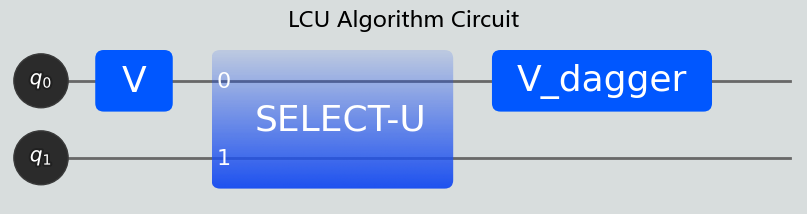

In [5]:
# 官方实现
from unitarylab import Circuit
from unitarylab_algorithms import LCUAlgorithm

U_I = Circuit(1, name="I")
U_I.i(0)

U_X = Circuit(1, name="X")
U_X.x(0)

%matplotlib inline
lcu_algorithm = LCUAlgorithm(text_mode="plain")
lcu_result = lcu_algorithm.run(
    alphas=[
        alpha_0,
        alpha_1,
    ],  # 注意系数应该非负, 若需要系数为负, 要将其吸收进对应的 unitary 中
    unitaries=[U_I, U_X],
    n_sys=1,
    initial_state=None,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [6]:
# 更底层的量子计算库
from unitarylab.library import LCU

lcu_library_circuit = LCU([(U_I, alpha_0), (U_X, alpha_1)])

In [7]:
# 官方数值结果
official_success_probability = lcu_result["Success probability"]
official_result_state = np.asarray(lcu_result["Result state"])

print("Official success probability =", official_success_probability)
print("Official result state =", official_result_state)

Official success probability = 0.5200000000000001
Official result state = [0.6+0.j 0.4+0.j]


In [8]:
# 对比
psi = np.array([1, 0], dtype=complex)

manual_result_state = A / alpha @ psi
manual_success_probability = float(
    np.vdot(manual_result_state, manual_result_state).real
)

print("\n========== LCU Comparison ==========")
print("Manual result state =", manual_result_state)
print("Official result state =", official_result_state)

print("Manual success probability =", manual_success_probability)
print("Official success probability =", official_success_probability)


========== LCU Comparison ==========
Manual result state = [0.6+0.j 0.4+0.j]
Official result state = [0.6+0.j 0.4+0.j]
Manual success probability = 0.5199999999999999
Official success probability = 0.5200000000000001


## Block Encoding 数学原理

### 1. Block Encoding 定义
其实上述 LCU 过程就是一个 Block Encoding 的过程, Block Encoding 的定义如下: 

若一个 unitary $U_A$ 满足:
$$
(\bra{0^a}\otimes I)U_A(\ket{0^a}\otimes I)=\frac{A}{\alpha}
$$
则称 $U_A$ 为是 A 的一个 $(\alpha, a, 0)-block\ encoding$(A 不一定是 unitary). 矩阵形式为
$$
U_A=\begin{bmatrix}
A/\alpha & * \\
* & *
\end{bmatrix}
$$
其中 $*$ 是什么通常不重要, 重要的是左上角.


### 2. 为什么需要 $\alpha$?
因为 unitary 的任何子块都必须满足
$$
\left\|\frac{A}{\alpha}\right\| \leq 1
$$
所以必须
$$
\alpha\geq \|A\|
$$
LCU 给出一个简单的选择方式
$$
\alpha = \sum_j|\alpha_j|
$$

### 3. 手写一个 Block Encoding
对于
$$
B=\frac{A}{\alpha}
$$
可以构造
$$
U_B=\begin{pmatrix}
B & \sqrt{I-B^2}\\
\sqrt{I-B^2} & -B
\end{pmatrix}
$$
本例为
$$
B=\begin{pmatrix}
0.6 & 0.4\\
0.4 & 0.6
\end{pmatrix}
$$

In [9]:
# 手写 Block Encoding
B = A / alpha

eigenvalues, eigenvectors = np.linalg.eigh(B)
sqrt_values = np.sqrt(np.clip(1 - eigenvalues**2, 0, None))
sqrt_term = eigenvectors @ np.diag(sqrt_values) @ eigenvectors.conj().T

U_block_manual = np.block([[B, sqrt_term], [sqrt_term, -B]])

# 验证其 unitary
manual_be_unitarity_error = np.linalg.norm(
    U_block_manual.conj().T @ U_block_manual - np.eye(4)
)

print("Manual block-encoding unitarity error =", manual_be_unitarity_error)

Manual block-encoding unitarity error = 7.554973438994227e-16


In [10]:
# 验证左上角
manual_be_block = U_block_manual[:2, :2]
manual_be_error = np.linalg.norm(manual_be_block - B)

print("Manual block error =", manual_be_error)

Manual block error = 0.0


### 4. Block Encoding 不唯一
现在已经构造了两个 Block Encoding $W_{LCU}$ 和 $U_{block}$, 整体上 $W_{LCU}\neq U_{block}$, 但是
$$
(W_{LCU})_{00} = (U_{block})_{00} = \frac{A}{\alpha}
$$
所以 Block Encoding 不唯一, 因为存在多个 Block Encoding 可以实现相同的功能.真正重要的是被投影出来的 block.

In [11]:
# 官方使用
from unitarylab.library import block_encode

be_result = block_encode(A, method="nagy", eps=1e-12, verbose=False)
"""
当前官方 API 支持 method="nagy" 和 method="fable" 两种方法
method="nagy" 是基于 SVD 的精确 block encoding
method="fable" 是带 eps 压缩阈值的 approximate block encoding
"""
be_circuit = be_result.circuit
be_alpha = be_result.alpha

total_qubits = be_result.total_qubits
target_qubits = be_result.target_qubits

print("Block-encoding alpha =", be_alpha)
print("Total qubits =", total_qubits)
print("Target qubits =", target_qubits)

Block-encoding alpha = 1.5000000149011614
Total qubits = 2
Target qubits = 1


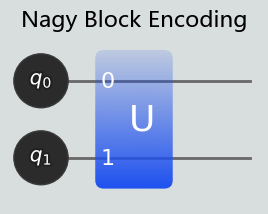

In [12]:
# 绘制线路图
_ = be_circuit.draw(title="Nagy Block Encoding")

In [13]:
# 从官方数值结果重建 unitary
def circuit_to_matrix(circuit):
    n_qubits = circuit.get_num_qubits()
    dimension = 2**n_qubits

    matrix = np.zeros((dimension, dimension), dtype=complex)

    for column in range(dimension):
        basis_state = np.zeros(dimension, dtype=complex)
        basis_state[column] = 1.0

        probe = Circuit(basis_state)
        probe.append(circuit, target=list(range(n_qubits)))

        result = probe.execute(backend="numpy", device="cpu", dtype=np.complex128)
        matrix[:, column] = result.state

    return matrix


# 验证官方 LCU 是 Block Encoding
official_lcu_circuit = LCU(
    [
        (U_I, alpha_0),
        (U_X, alpha_1),
    ]
)
official_lcu_matrix = circuit_to_matrix(official_lcu_circuit)
official_lcu_block = official_lcu_matrix[::2, ::2]

official_lcu_block_error = np.linalg.norm(official_lcu_block - A / alpha)

print("Official LCU block error =", official_lcu_block_error)


Official LCU block error = 2.0014830212433605e-16


In [14]:
# 验证官方 Block Encoding
official_be_matrix = circuit_to_matrix(be_circuit)
system_dimension = 2**target_qubits
official_be_block = official_be_matrix[:system_dimension, :system_dimension]

expected_be_block = A / be_alpha
official_be_error = np.linalg.norm(official_be_block - expected_be_block)

print("Official block-encoding error =", official_be_error)

Official block-encoding error = 5.551115123125783e-17


In [15]:
print("\n========== Block Encoding Comparison ==========")
print("Manual LCU block error =", manual_lcu_block_error)
print("Official LCU block error =", official_lcu_block_error)
print("Manual dilation block error =", manual_be_error)
print("Official Nagy block error =", official_be_error)


========== Block Encoding Comparison ==========
Manual LCU block error = 1.7554167342883506e-16
Official LCU block error = 2.0014830212433605e-16
Manual dilation block error = 0.0
Official Nagy block error = 5.551115123125783e-17


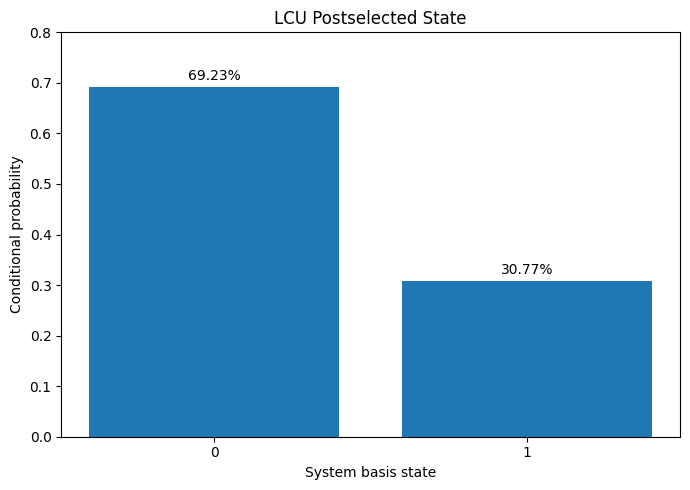

In [16]:
# 后选择概率
import matplotlib.pyplot as plt

conditional_probabilities = np.abs(manual_result_state) ** 2
conditional_probabilities /= conditional_probabilities.sum()

basis_states = ["0", "1"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(basis_states, conditional_probabilities)
ax.bar_label(
    bars, labels=[f"{p * 100:.2f}%" for p in conditional_probabilities], padding=3
)

ax.set_xlabel("System basis state")
ax.set_ylabel("Conditional probability")
ax.set_title("LCU Postselected State")
ax.set_ylim(0, 0.8)

fig.tight_layout()

plt.show()